# Desafio Técnico — Cientista de Dados Pleno / Squad WhatsApp
**Prefeitura do Rio de Janeiro**

**Parte 1 — EDA e Qualidade das Fontes**
Desestruturação, merge, distribuição de status, decaimento temporal e performance por sistema.

**Parte 2 — Inteligência de Priorização**
Score composto: frescor do dado → Wilson LB por sistema → bônus DDD. Seleção Top-2 por CPF.

**Parte 3 — Desenho do Experimento A/B**
Hipótese, métricas, tamanho amostral, randomização por hash de CPF e template de medição.

In [ ]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Paths — notebook em notebooks/, logo .. = raiz do projeto
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
sys.path.insert(0, str(PROJECT_ROOT))
OUTPUT_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Parâmetros de seleção
# ---------------------------------------------------------------------------
TOP_N        = 2    # telefones selecionados por CPF
MIN_DISPAROS = 100  # volume mínimo para incluir sistema no ranking

# Scoring — hiperparâmetros do algoritmo
# half_life removido: taxa de decaimento é um detalhe de implementação fixo em scoring.py
SCORING = dict(
    w_sistema = 0.50,
    w_frescor = 0.40,
    w_ddd     = 0.10,
)

# DDD 21 (Rio de Janeiro) — valor int64 mascarado identificado via EDA
DDD_ALVO = frozenset({-1181433720517268842})

# ---------------------------------------------------------------------------
# Parâmetros A/B
# ---------------------------------------------------------------------------
AB_P1    = 0.26
AB_P2    = 0.30
AB_ALPHA = 0.05
AB_POWER = 0.80

# ---------------------------------------------------------------------------
# Paletas visuais
# ---------------------------------------------------------------------------
PALETTE_STATUS = {
    "delivered": "#2ecc71",
    "read":      "#3498db",
    "failed":    "#e74c3c",
    "sent":      "#f39c12",
    "processing":"#95a5a6",
}
CORES_AB = {"A": "#3498db", "B": "#e74c3c"}

print(f"SCORING      → {SCORING}")

PROJECT_ROOT → C:\Users\thiag\OneDrive\Documentos\desafio-tecnico\desafio-cientista-dados-pleno-campanhas
SCORING      → {'w_sistema': 0.5, 'w_frescor': 0.4, 'w_ddd': 0.1}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import mannwhitneyu, kruskal

from src.utils import load_parquets, explode_aparicoes, build_merged, resumo_eda
from src.scoring import (
    calcular_performance_sistemas,
    calcular_score_frescor_vectorised,
    calcular_scores_batch,
    selecionar_top_n,
    calcular_tamanho_amostra,
)
from src.plots import (
    configure_plots,
    plot_status_bar,
    plot_decaimento,
    plot_ranking_sistemas,
    plot_score_kde,
    plot_curva_poder,
    plot_ab_treemap,
)

configure_plots(dpi=130)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


Imports OK


---
# Parte 1 — EDA e Qualidade das Fontes

## 1.1 Carga e Auditoria

`base_disparo_mascarado` — histórico real de disparos: um registro por mensagem enviada, com status final e número de telefone contatado.

`dim_telefone_mascarado` — dimensão de telefones: de quais sistemas cada número é conhecido e quando foi atualizado pela última vez. A coluna `telefone_aparicoes` armazena uma lista de dicionários (um por sistema) que será desestruturada no próximo passo.

In [3]:
df_disparo, df_telefone = load_parquets(DATA_DIR)
print(f"base_disparo_mascarado : {df_disparo.shape[0]:,} × {df_disparo.shape[1]}")
print(f"dim_telefone_mascarado : {df_telefone.shape[0]:,} × {df_telefone.shape[1]}")
display(resumo_eda(df_disparo, df_telefone))

base_disparo_mascarado : 392,921 × 16
dim_telefone_mascarado : 283,289 × 11


,tabela,coluna,dtype,nulos,pct_nulo,cardinalidade
0,base_disparo,id_conta,int64,0,0.0000,1
1,base_disparo,id_hsm,int64,0,0.0000,68
2,base_disparo,id_disparo,int64,0,0.0000,392921
3,base_disparo,id_sessao,float64,156017,39.7100,229123
4,base_disparo,cpf,float64,31176,7.9300,268437
5,base_disparo,id_target,int64,0,0.0000,392921
6,base_disparo,contato_telefone,int64,0,0.0000,294903
7,base_disparo,categoria_hsm,str,0,0.0000,4
8,base_disparo,ambiente,str,0,0.0000,4
9,base_disparo,criacao_envio_datahora,datetime64[us],0,0.0000,392675


In [4]:
# Colunas com nulos — verificação rápida
dq = resumo_eda(df_disparo, df_telefone)
com_nulos = dq[dq["nulos"] > 0][["tabela", "coluna", "pct_nulo"]].reset_index(drop=True)

print("Colunas com valores ausentes:")
display(com_nulos)
print()
print("Diagnóstico:")
print("  falha_datahora / descricao_falha (93 %) — preenchidos apenas em falhas. Comportamento esperado.")
print("  id_sessao (39 %)        — coluna não utilizada na análise.")
print("  cpf em base_disparo (8 %) — CPFs sem cadastro; excluídos naturalmente pelo inner join.")
print()
print("As colunas críticas para a análise (id_disparo, contato_telefone,")
print("status_disparo, telefone_numero, telefone_aparicoes) não possuem nulos.")


Colunas com valores ausentes:


,tabela,coluna,pct_nulo
0,base_disparo,id_sessao,39.7100
1,base_disparo,cpf,7.9300
2,base_disparo,falha_datahora,93.0600
3,base_disparo,descricao_falha,93.0600



Diagnóstico:
  falha_datahora / descricao_falha (93 %) — preenchidos apenas em falhas. Comportamento esperado.
  id_sessao (39 %)        — coluna não utilizada na análise.
  cpf em base_disparo (8 %) — CPFs sem cadastro; excluídos naturalmente pelo inner join.

As colunas críticas para a análise (id_disparo, contato_telefone,
status_disparo, telefone_numero, telefone_aparicoes) não possuem nulos.


## 1.2 Distribuição de Status

`read` e `delivered` representam mais de 90 % dos disparos. Usamos `delivered` como métrica de sucesso — entrega confirmada no dispositivo, independente de leitura.

,status,pct
0,read,69.1147
1,delivered,21.7359
2,failed,6.9370
3,sent,1.4082
4,processing,0.8042


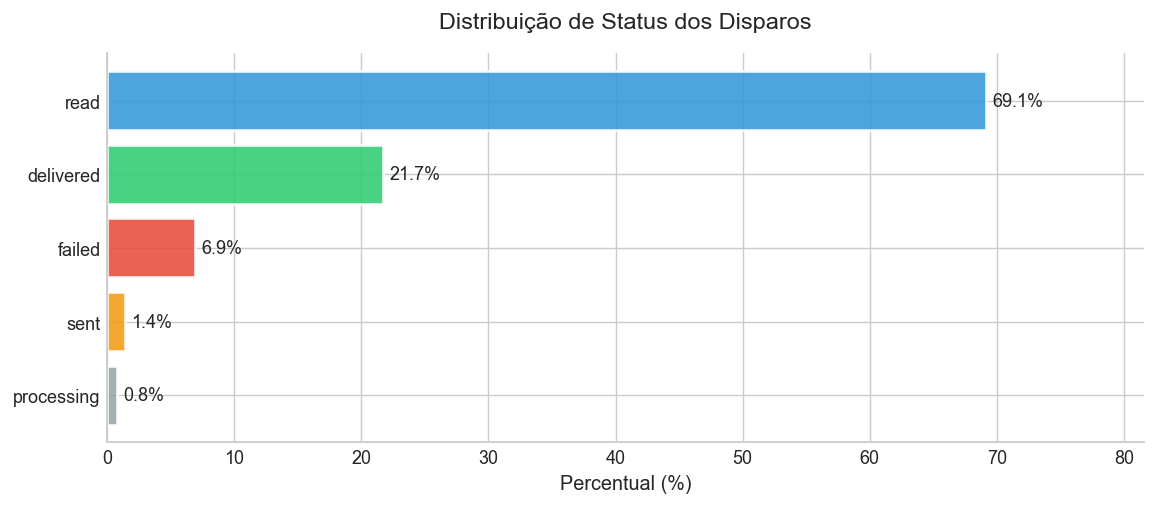

In [5]:
status_counts = (
    df_disparo["status_disparo"]
    .value_counts(normalize=True).mul(100)
    .rename_axis("status").reset_index(name="pct")
)
display(status_counts)
plot_status_bar(status_counts, PALETTE_STATUS, OUTPUT_DIR);

## 1.3 Desestruturação e Merge

`telefone_aparicoes` é uma lista de dicts com `id_sistema`, `cpf`, `proprietario_tipo` e `registro_data_atualizacao`. O pipeline abaixo a expande via `explode + json_normalize` vetorizado e faz inner join com o histórico.

Inner join é intencional: só analisamos telefones com histórico real de disparo. Sem evidência não há qualidade mensurável.

In [6]:
df_tels_sistemas = explode_aparicoes(df_telefone)
df_merged        = build_merged(df_disparo, df_tels_sistemas)
hoje             = pd.Timestamp.now()

print(f"Após explode : {df_tels_sistemas.shape[0]:,} linhas  (uma por telefone × sistema)")
print(f"Após merge   : {df_merged.shape[0]:,} linhas")
print(f"Taxa global de entrega: {df_merged['is_delivered'].mean():.2%}")

Após explode : 1,529,772 linhas  (uma por telefone × sistema)
Após merge   : 6,294,306 linhas
Taxa global de entrega: 37.26%


## 1.4 Janela de Atualidade — Decaimento Temporal

Analisamos o decaimento da qualidade do dado **antes** do ranking de sistemas, pois o frescor é o sinal com segunda maior influência no score composto.

A ausência do bucket `0-3m` é um achado crítico: **todo o dataset tem pelo menos 6 meses de defasagem**. A dimensão de telefones não é atualizada em tempo real — reforçando a necessidade de penalizar dados antigos.

In [7]:
df_merged["dias_desde_atualizacao"] = (
    hoje - pd.to_datetime(df_merged["registro_data_atualizacao"])
).dt.days

df_merged["meses_cat"] = pd.cut(
    df_merged["dias_desde_atualizacao"] // 30,
    bins=[0, 3, 6, 12, 24, 36, 10_000],
    labels=["0-3m", "3-6m", "6-12m", "1-2a", "2-3a", ">3a"],
)

time_perf = (
    df_merged
    .groupby("meses_cat", observed=True)["is_delivered"]
    .agg(taxa="mean", n="count")
    .reset_index()
)

print("Taxa de entrega por faixa etária do dado:")
display(time_perf)
print(f"\nDado mais recente : {pd.to_datetime(df_merged['registro_data_atualizacao']).max().date()}")


Taxa de entrega por faixa etária do dado:


,meses_cat,taxa,n
0,3-6m,0.2761,151757
1,6-12m,0.2570,644125
2,1-2a,0.3241,522457
3,2-3a,0.3017,179021
4,>3a,0.2851,110258



Dado mais recente : 2025-11-22


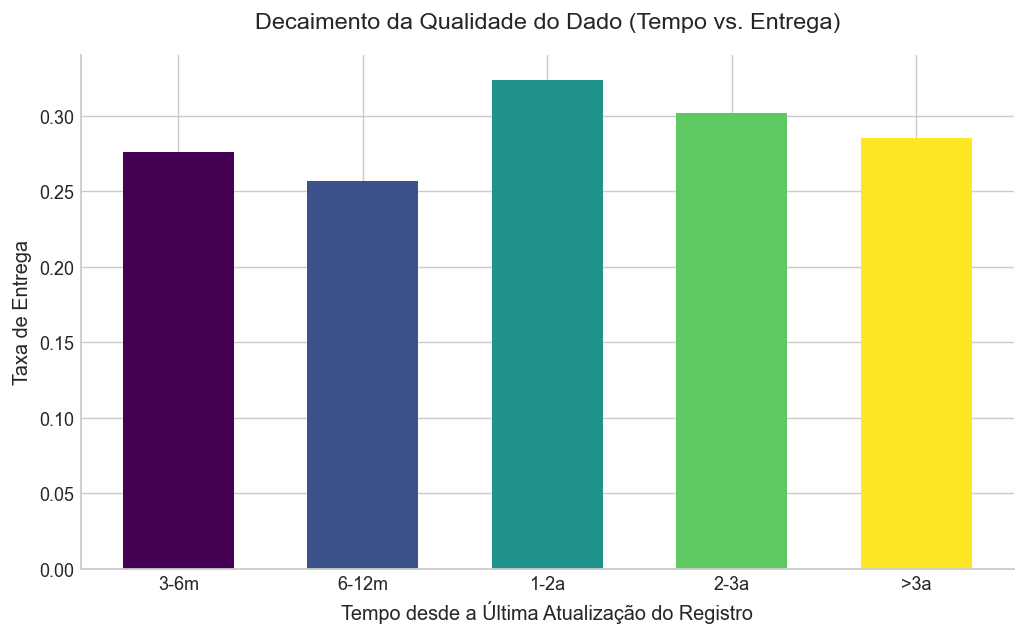

In [8]:
plot_decaimento(time_perf, OUTPUT_DIR);


## 1.5 Testes Estatísticos

Como `is_delivered` é binária (Bernoulli), testes paramétricos que assumem normalidade são inadequados. Usamos:

**Mann-Whitney U** — H₀: entregas do melhor e pior sistema têm a mesma distribuição.

**Kruskal-Wallis H** — H₀: medianas de entrega são iguais em todos os sistemas.

**OLS log-linear** — quantifica o coeficiente do decaimento temporal via `log(dias)`.

In [9]:
# Calcula performance aqui para ter sistemas_rank antes dos testes
performance  = calcular_performance_sistemas(df_merged, min_disparos=MIN_DISPAROS)
sistemas_rank = performance.index.tolist()

g_melhor = df_merged[df_merged["id_sistema"] == sistemas_rank[0]]["is_delivered"].astype(int)
g_pior   = df_merged[df_merged["id_sistema"] == sistemas_rank[-1]]["is_delivered"].astype(int)

stat_mw, p_mw = mannwhitneyu(g_melhor, g_pior, alternative="greater")
stat_kw, p_kw = kruskal(*[
    df_merged[df_merged["id_sistema"] == s]["is_delivered"].astype(int).values
    for s in sistemas_rank
])

print(f"Mann-Whitney U — melhor ({sistemas_rank[0]}) vs pior ({sistemas_rank[-1]})")
print(f"  p = {p_mw:.4f}  → {'H₀ REJEITADA' if p_mw < AB_ALPHA else 'H₀ não rejeitada'}")
print()
print(f"Kruskal-Wallis H — {len(sistemas_rank)} sistemas")
print(f"  p = {p_kw:.2e}  → {'H₀ REJEITADA' if p_kw < AB_ALPHA else 'H₀ não rejeitada'}")

Mann-Whitney U — melhor (1257277410380486863) vs pior (-4704067261970591609)
  p = 0.0000  → H₀ REJEITADA

Kruskal-Wallis H — 6 sistemas
  p = 0.00e+00  → H₀ REJEITADA


In [10]:
df_ols = (
    df_merged[["is_delivered", "dias_desde_atualizacao"]]
    .dropna().query("dias_desde_atualizacao > 0").copy()
)
df_ols["log_dias"] = np.log1p(df_ols["dias_desde_atualizacao"])

modelo_ols = sm.OLS(
    df_ols["is_delivered"].astype(float),
    sm.add_constant(df_ols["log_dias"])
).fit()

coef = modelo_ols.params["log_dias"]
print(modelo_ols.summary())
print(f"\nCoef log_dias = {coef:+.4f} | p = {modelo_ols.pvalues['log_dias']:.2e}")

                            OLS Regression Results                            
Dep. Variable:           is_delivered   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2073.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:54:54   Log-Likelihood:            -1.0056e+06
No. Observations:             1607618   AIC:                         2.011e+06
Df Residuals:                 1607616   BIC:                         2.011e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1299      0.003     37.318      0.0

## 1.6 Correlação: Sistema de Origem × Taxa de Entrega

Entregável 1 do desafio: análise comparativa das taxas de entrega (`delivered`) agregadas por `id_sistema`.

A taxa bruta (sucessos / n) sofre viés de volume — o disclaimer do enunciado já alertava: alguns sistemas aparecem com mais tentativas porque são considerados "mais quentes" pela operação, não necessariamente porque entregam melhor. O gráfico da seção 2.1 corrige isso com Wilson Lower Bound.


In [11]:
print("Performance por sistema (mínimo 100 disparos):")
display(performance)
print(f"\nDiferença taxa bruta  — melhor vs pior: {performance['taxa_bruta'].max() - performance['taxa_bruta'].min():.2%}")
print(f"Volume — maior sistema: {performance['total_disparos'].max():,.0f}")
print(f"Volume — menor sistema: {performance['total_disparos'].min():,.0f}")

Performance por sistema (mínimo 100 disparos):


,total_disparos,sucessos,taxa_bruta,wilson_score
id_sistema,,,,
1257277410380486863,1550353,618138,0.3987,0.3979
-133612832286195827,3791783,1491897,0.3935,0.3930
4458959843028638627,53053,18328,0.3455,0.3414
-2757366171786647144,10908,3568,0.3271,0.3184
3094574413675758272,690985,170746,0.2471,0.2461
-4704067261970591609,197224,42372,0.2148,0.2130



Diferença taxa bruta  — melhor vs pior: 18.39%
Volume — maior sistema: 3,791,783
Volume — menor sistema: 10,908


---
# Parte 2 — Inteligência de Priorização

## 2.1 Ranking de Sistemas: Wilson Lower Bound

Entregável 3 do desafio: ranking de confiabilidade com explicação matemática.

O WLB calcula o **limite inferior do intervalo de confiança de 95 %** para a proporção real, penalizando automaticamente a incerteza estatística — quanto menor o volume, maior o desconto:

$$WLB = \frac{\hat{p} + \frac{z^2}{2n} - z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

**Por que o sistema 1257... é melhor que o -4704...?**
O sistema 1257 tem WLB = 0,3979 com 1,55 M tentativas. O sistema -4704 tem WLB = 0,2130 com 197 k tentativas. A diferença de ~19 p.p. é estatisticamente robusta a 95 % CI — não é artefato de volume.

No gráfico de barras abaixo, a barra vermelha mostra a taxa bruta e a verde mostra o WLB. A diferença entre as duas barras é o **desconto de incerteza** aplicado pelo Wilson LB — sistemas com menor n recebem desconto maior.


In [12]:
melhor = performance.iloc[0]
pior   = performance.iloc[-1]
print(f"Melhor — WLB={melhor['wilson_score']:.4f}  taxa_bruta={melhor['taxa_bruta']:.4f}  n={melhor['total_disparos']:,.0f}")
print(f"Pior   — WLB={pior['wilson_score']:.4f}  taxa_bruta={pior['taxa_bruta']:.4f}  n={pior['total_disparos']:,.0f}")
print(f"Diferença WLB: {melhor['wilson_score'] - pior['wilson_score']:.2%}")

Melhor — WLB=0.3979  taxa_bruta=0.3987  n=1,550,353
Pior   — WLB=0.2130  taxa_bruta=0.2148  n=197,224
Diferença WLB: 18.49%


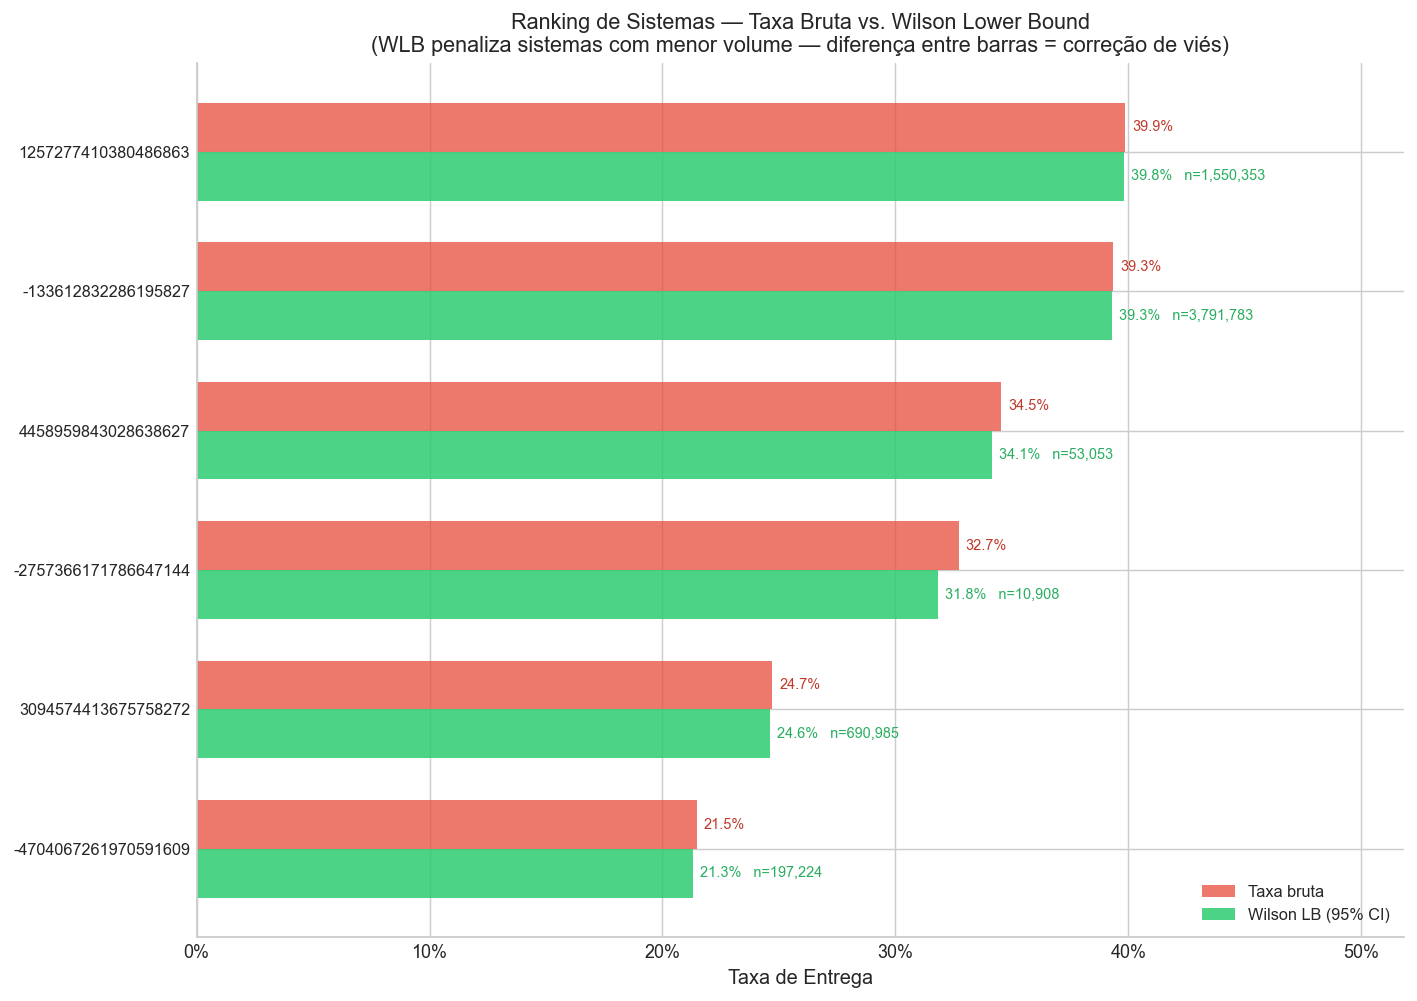

In [13]:
plot_ranking_sistemas(performance, OUTPUT_DIR);

## 2.2 Score Composto — Ordem de Cálculo

O score combina três sinais em um valor único por par `(telefone × sistema)`. A ordem de cálculo reflete a prioridade analítica estabelecida na EDA:

$$S = 0{,}40 \cdot \underbrace{e^{-\lambda t}}_{\text{frescor (1°)}} + 0{,}50 \cdot \underbrace{WLB_{\text{sistema}}}_{\text{Wilson (2°)}} + 0{,}10 \cdot \underbrace{\mathbb{1}[DDD \in \text{DDD\_ALVO}]}_{\text{DDD (3°)}}$$

λ é uma constante interna do módulo — não exposta como parâmetro configurável.

**Prevenção de data leakage:** o score é calculado sobre `df_tels_sistemas` (tabela dimensão), nunca sobre o histórico de disparos.

In [14]:
# Passo 1 — Frescor (decaimento exponencial)
df_tels_sistemas["score_frescor"] = calcular_score_frescor_vectorised(
    df_tels_sistemas["registro_data_atualizacao"], hoje
)
print("Score de frescor:")
print(f"  min={df_tels_sistemas['score_frescor'].min():.4f}  "
      f"median={df_tels_sistemas['score_frescor'].median():.4f}  "
      f"max={df_tels_sistemas['score_frescor'].max():.4f}")

Score de frescor:
  min=0.0000  median=0.0416  max=0.5442


In [15]:
# Passo 2 — Wilson por sistema (já calculado em performance)
sistema_scores = performance["wilson_score"]

# Passo 3 — Score composto vetorizado (**SCORING desempacota w_sistema, w_frescor, w_ddd)
df_tels_sistemas["score"] = calcular_scores_batch(
    df_tels_sistemas,
    sistema_scores=sistema_scores,
    hoje=hoje,
    ddds_alvo=DDD_ALVO,
    **SCORING,
)

print(f"Score composto — {len(df_tels_sistemas):,} registros")
print(f"min={df_tels_sistemas['score'].min():.4f}  "
      f"median={df_tels_sistemas['score'].median():.4f}  "
      f"max={df_tels_sistemas['score'].max():.4f}")
display(
    df_tels_sistemas
    .nlargest(5, "score")[["cpf", "telefone_numero", "id_sistema",
                            "registro_data_atualizacao", "score_frescor", "score"]]
)

Score composto — 1,529,772 registros
min=0.1241  median=0.2971  max=0.5117


,cpf,telefone_numero,id_sistema,registro_data_atualizacao,score_frescor,score
825136,-1439243084157348544,-7377032298027383101,1257277410380486863,2025-11-16,0.5318,0.5117
514,2416395918735157267,4394291304418644479,1257277410380486863,2025-11-15,0.5297,0.5109
1100,-8575728341520331890,-5616600118579779256,1257277410380486863,2025-11-15,0.5297,0.5109
1391,6186032905018277284,-1829366691099273923,1257277410380486863,2025-11-15,0.5297,0.5109
2535,3419104677851755342,6483338755657120734,1257277410380486863,2025-11-15,0.5297,0.5109


## 2.3 Top-2 por CPF

Selecionamos os dois telefones com maior score por CPF. O Top-2 garante fallback: se o primeiro falhar (desligado, caixa cheia), o motor tenta o segundo antes de desistir. Seleção via `groupby + rank` — O(n log k), sem loops Python.

In [16]:
df_top = selecionar_top_n(
    df_tels_sistemas, id_cidadao_col="cpf", score_col="score", n=TOP_N
)

lift    = (df_top["score"].mean() / df_tels_sistemas["score"].mean() - 1) * 100
reducao = (1 - len(df_top) / len(df_tels_sistemas)) * 100

print(f"Total         : {len(df_tels_sistemas):>10,}")
print(f"Top-{TOP_N} selecionados: {len(df_top):>10,}")
print(f"CPFs cobertos : {df_top['cpf'].nunique():>10,}")
print(f"Redução volume: {reducao:>9.1f}%")
print(f"Lift score    : +{lift:.1f}%")
print(f"Máx tel/CPF   : {df_top.groupby('cpf').size().max()} (≤ {TOP_N} ✓)")

Total         :  1,529,772
Top-2 selecionados:  1,457,806
CPFs cobertos :  1,221,517
Redução volume:       4.7%
Lift score    : +0.1%
Máx tel/CPF   : 2 (≤ 2 ✓)


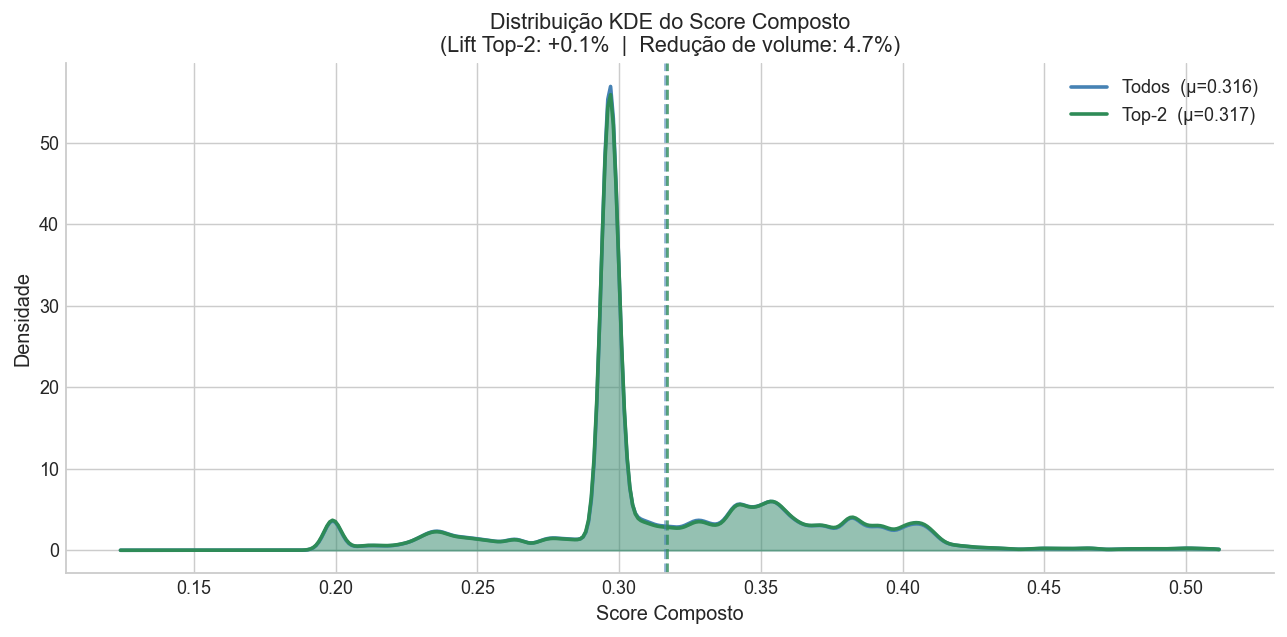

In [17]:
plot_score_kde(df_tels_sistemas, df_top, TOP_N, lift, reducao, OUTPUT_DIR);

In [18]:
df_top.to_parquet(OUTPUT_DIR / "top2_por_cpf.parquet", index=False)
print(f"Output: {(OUTPUT_DIR / 'top2_por_cpf.parquet').resolve()}")
print(f"{len(df_top):,} registros  |  {df_top['cpf'].nunique():,} CPFs únicos")

Output: C:\Users\thiag\OneDrive\Documentos\desafio-tecnico\desafio-cientista-dados-pleno-campanhas\outputs\top2_por_cpf.parquet
1,457,806 registros  |  1,221,517 CPFs únicos


---
# Parte 3 — Desenho do Experimento A/B

## 3.1 Hipóteses e Métricas

**Grupos**

Grupo A (Controle) — seleção aleatória de um número entre os vinculados ao CPF, como hoje. Grupo B (Tratamento) — Top-1 do algoritmo de score para cada CPF.

**Hipóteses**

H₀: p_B ≤ p_A — o algoritmo não melhora a entrega. H₁: p_B > p_A — unicaudal, pois esperamos melhora.

**Métrica primária**

Delivery Rate: proporção de disparos com `status = delivered`. Única métrica que o algoritmo otimiza diretamente.

**Métricas secundárias**

Custo por cidadão engajado: reduzir tentativas falhas diminui o custo unitário mesmo com preço fixo por disparo.

Taxa de opt-out (guardrail): se ultrapassar 2 % no grupo B, o experimento é interrompido.

**Parâmetros**

Baseline de 26 % vem do histórico EDA. MDE de +4 p.p. é o mínimo economicamente justificável — abaixo disso a redução de custo não amortiza o esforço de manutenção do algoritmo.

In [19]:
n_por_grupo = calcular_tamanho_amostra(AB_P1, AB_P2, AB_ALPHA, AB_POWER)

print(f"Baseline p₁  : {AB_P1:.0%}")
print(f"MDE p₂       : {AB_P2:.0%}  (+{(AB_P2-AB_P1)*100:.0f} p.p.)")
print(f"α / poder    : {AB_ALPHA:.0%} / {AB_POWER:.0%}")
print(f"N por grupo  : {n_por_grupo:,}")
print(f"Total amostra: {n_por_grupo * 2:,}")
print()
diario = 392_921 // 365 // 10
print(f"Duração estimada: ~{int(np.ceil(n_por_grupo / diario))} dias "
      f"com 10 % do volume diário ({diario:,} disparos/dia no grupo B)")

Baseline p₁  : 26%
MDE p₂       : 30%  (+4 p.p.)
α / poder    : 5% / 80%
N por grupo  : 1,557
Total amostra: 3,114

Duração estimada: ~15 dias com 10 % do volume diário (107 disparos/dia no grupo B)


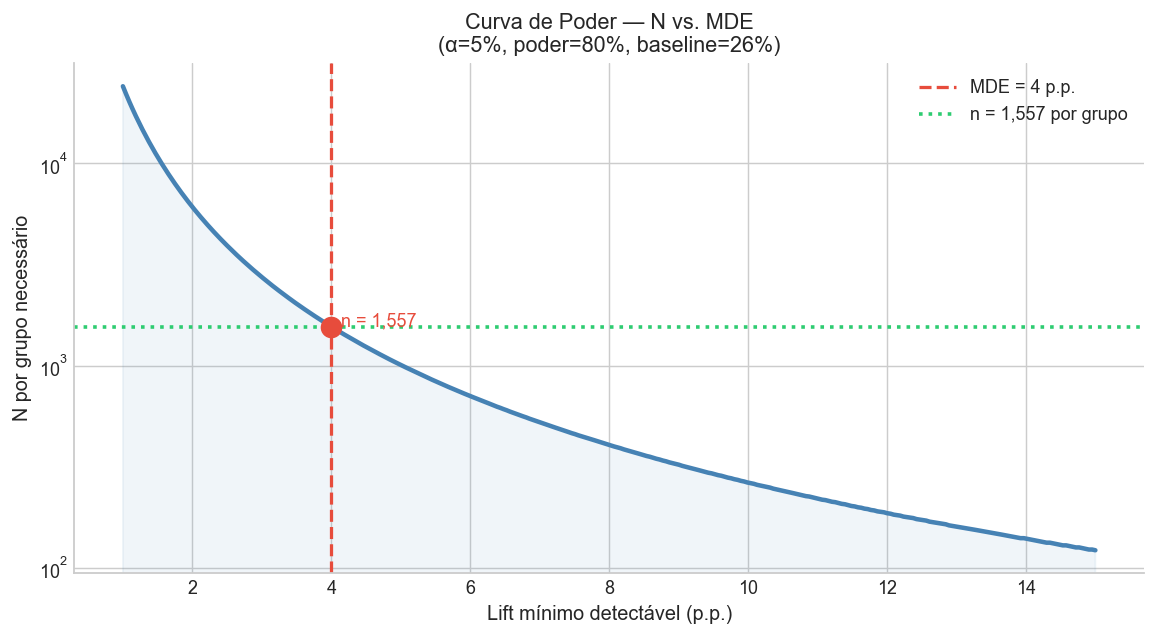

In [20]:
plot_curva_poder(AB_P1, AB_P2, n_por_grupo, AB_ALPHA, AB_POWER, OUTPUT_DIR);

## 3.2 Randomização

Dividimos os CPFs em dois grupos iguais de forma aleatória, com semente fixa para garantir que o experimento seja reproduzível.


In [21]:
cpfs_unicos = (
    df_tels_sistemas["cpf"]
    .drop_duplicates()
    .sample(n=n_por_grupo * 2, random_state=42)
    .reset_index(drop=True)
)

metade = len(cpfs_unicos) // 2
cpfs_ab = pd.DataFrame({
    "cpf":      cpfs_unicos,
    "ab_grupo": ["A"] * metade + ["B"] * (len(cpfs_unicos) - metade),
})

dist_ab = cpfs_ab["ab_grupo"].value_counts()
print(f"A = {dist_ab.get('A', 0):,}  |  B = {dist_ab.get('B', 0):,}")


A = 1,557  |  B = 1,557


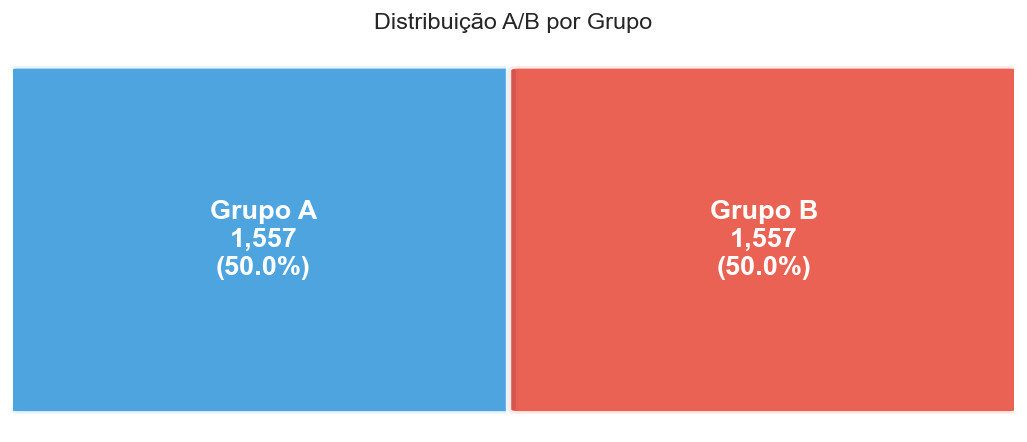

In [22]:
plot_ab_treemap(dist_ab, CORES_AB, OUTPUT_DIR);

## 3.3 Medição ao Fim do Teste

Teste Z para proporções independentes (unicaudal). H₀ rejeitada se p-value < α = 5 %. Sem análises intermediárias (peeking) para não inflar o erro tipo I. Única causa de interrupção antecipada: violação do guardrail de opt-out.

In [23]:
from statsmodels.stats.proportion import proportions_ztest

# Substituir pelos dados reais ao fim do experimento
SUCESSOS_A, TOTAL_A = 340, 1_300
SUCESSOS_B, TOTAL_B = 420, 1_400

stat_z, p_valor = proportions_ztest(
    count=[SUCESSOS_B, SUCESSOS_A],
    nobs=[TOTAL_B, TOTAL_A],
    alternative="larger",
)

print("Teste Z para Proporções (unicaudal — B > A)")
print(f"  Taxa A: {SUCESSOS_A/TOTAL_A:.2%}  |  Taxa B: {SUCESSOS_B/TOTAL_B:.2%}")
print(f"  Uplift: +{(SUCESSOS_B/TOTAL_B - SUCESSOS_A/TOTAL_A)*100:.1f} p.p.")
print(f"  Z = {stat_z:.3f}  |  p-value = {p_valor:.4f}")
print()
if p_valor < AB_ALPHA:
    print(f"  → H₀ REJEITADA (α={AB_ALPHA}) — algoritmo melhora a entrega.")
    print("     Recomendação: graduar rollout para 100 % da base.")
else:
    print("  → H₀ não rejeitada — sem evidência de melhora.")
    print("     Recomendação: revisar pesos do SCORING ou estender período.")

Teste Z para Proporções (unicaudal — B > A)
  Taxa A: 26.15%  |  Taxa B: 30.00%
  Uplift: +3.8 p.p.
  Z = 2.220  |  p-value = 0.0132

  → H₀ REJEITADA (α=0.05) — algoritmo melhora a entrega.
     Recomendação: graduar rollout para 100 % da base.
